In [1]:
import torch

from tts.config.ndaligner.data_config import DataConfig
from tts.config.ndaligner.training_module_config import NDAlignerTrainingModuleConfigs
from tts.config.utils.io import load_config
from tts.models.ndaligner import init_nd_aligner_training_module

/home/blue2959/monotonic_tts/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

aligner_data_cfg_path = "./runs/nd_aligner_vctk_v1.4_ablation_20260701-004509/data_config.json"
aligner_training_module_cfg_path = "./runs/nd_aligner_vctk_v1.4_ablation_20260701-004509/model_config.json"
aligner_training_module_ckpt_path = "./runs/nd_aligner_vctk_v1.4_ablation_20260701-004509/checkpoints_timit_bae/best_step_timit_bae_0.021225_step_81000_epoch_16.pth"

TIMIT_VISUALIZATION_ROOT = "/shared/data_zfs/blue2959/TIMIT_anal"

In [3]:
data_config = load_config(aligner_data_cfg_path, DataConfig)
model_config = load_config(aligner_training_module_cfg_path, NDAlignerTrainingModuleConfigs,)

aligner_training_module = init_nd_aligner_training_module(
    config=model_config,
    device=device,
)
aligner_training_module.load_checkpoint(
    ckpt_path=aligner_training_module_ckpt_path,
    device=device,
)
aligner = aligner_training_module.nd_aligner.eval()

/home/blue2959/monotonic_tts/.venv/lib/python3.13/site-packages/speechbrain/utils/autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)


SpeechBrain ECAPA-TDNN SpeakerEncoder loaded on cuda.
Loading nested state_dict from key 'model' in ./runs/nd_aligner_vctk_v1.4_ablation_20260701-004509/checkpoints_timit_bae/best_step_timit_bae_0.021225_step_81000_epoch_16.pth
⚠️ Checkpoint load summary (strict=False):
  - Missing top-level modules : ['nd_aligner']
  - Unexpected top-level modules: ['vocoder']
Checkpoint loading process finished.


In [4]:
from tts.tokenizer.espeak_tokenizer import ESPEAKTokenizer
from tts.models.modules.spk_encoder import ECAPASpeakerEncoder

txt_tokenizer = ESPEAKTokenizer()
spk_encoder = ECAPASpeakerEncoder(device=device)

SpeechBrain ECAPA-TDNN SpeakerEncoder loaded on cuda.


In [5]:
from pathlib import Path
import math

import torch
import matplotlib.pyplot as plt

from tts.benchmark.timit.word_mapper import WordsMapper, TimitWordSegment

TIMIT_VISUALIZATION_ROOT = Path("/shared/data_zfs/blue2959/TIMIT_anal")
SAMPLE_STEM = "SA2"  # change if needed

REF_AUDIO_SR = 16000
HYP_AUDIO_SR = 22050
HOP_LENGTH = 256
SEC_PER_FRAME = HOP_LENGTH / HYP_AUDIO_SR


def find_optional_path(root: Path, stem: str, suffixes: tuple[str, ...]) -> Path | None:
    for suffix in suffixes:
        path = root / f"{stem}{suffix}"
        if path.exists():
            return path
    return None


wav_path = find_optional_path(TIMIT_VISUALIZATION_ROOT, SAMPLE_STEM, (".WAV", ".wav"))
wrd_path = find_optional_path(TIMIT_VISUALIZATION_ROOT, SAMPLE_STEM, (".WRD", ".wrd"))
txt_path = find_optional_path(TIMIT_VISUALIZATION_ROOT, SAMPLE_STEM, (".TXT", ".txt"))
phn_path = find_optional_path(TIMIT_VISUALIZATION_ROOT, SAMPLE_STEM, (".PHN", ".phn"))

assert wav_path is not None, f"WAV not found for {SAMPLE_STEM}"
assert wrd_path is not None, f"WRD not found for {SAMPLE_STEM}"

print("WAV:", wav_path)
print("WRD:", wrd_path)
print("TXT:", txt_path)
print("PHN:", phn_path)

WAV: /shared/data_zfs/blue2959/TIMIT_anal/SA2.WAV
WRD: /shared/data_zfs/blue2959/TIMIT_anal/SA2.WRD
TXT: /shared/data_zfs/blue2959/TIMIT_anal/SA2.TXT
PHN: /shared/data_zfs/blue2959/TIMIT_anal/SA2.PHN


In [6]:
def read_timit_wrd(wrd_path: str | Path) -> list[TimitWordSegment]:
    segments = []
    with open(wrd_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            start, end, word = line.split(maxsplit=2)
            segments.append(
                TimitWordSegment(
                    start_sample=int(start),
                    end_sample=int(end),
                    word=word,
                )
            )
    return segments


def read_timit_txt(txt_path: str | Path) -> str:
    with open(txt_path, "r", encoding="utf-8") as f:
        line = f.readline().strip()

    parts = line.split(maxsplit=2)
    if len(parts) == 3 and parts[0].isdigit() and parts[1].isdigit():
        return parts[2]
    return line


wrd_segments = read_timit_wrd(wrd_path)
ref_words = [seg.word for seg in wrd_segments]

# If TXT is absent in the visualization folder, reconstruct text from WRD words.
text = read_timit_txt(txt_path) if txt_path is not None else " ".join(ref_words)

print("Text:")
print(text)
print()
print("WRD words:")
print(ref_words)

Text:
Don't ask me to carry an oily rag like that.

WRD words:
["don't", 'ask', 'me', 'to', 'carry', 'an', 'oily', 'rag', 'like', 'that']


In [7]:
assert aligner.input_maker is not None

aligner.eval()
aligner.input_maker.eval()
aligner.input_maker.to(device=device)

with torch.no_grad():
    batch = aligner.input_maker.make_with_audio(
        wav_paths=wav_path,
        scripts=[text],
    )

    cond = (
        torch.tensor(0.0, device=batch.x.device)
        if batch.cond is None
        else batch.cond
    )

    features = aligner.compute_alignments(
        x=batch.x,
        x_lengths=batch.x_lengths,
        y=batch.y,
        y_lengths=batch.y_lengths,
        cond=cond,
        compute_soft_path=True,
        compute_hard_path=True,
    )

text_len = int(batch.x_lengths[0].item())
mel_len = int(batch.y_lengths[0].item())

token_ids_1d = batch.x[0, :text_len].detach().cpu()
tokenizer = aligner.input_maker.tokenizer
hyp_symbols_raw = tokenizer.decode_to_symbols(token_ids_1d)

if len(hyp_symbols_raw) > 0 and isinstance(hyp_symbols_raw[0], list):
    raise ValueError("Expected 1D token symbols, got batched symbols.")

hyp_symbols = [str(sym) for sym in hyp_symbols_raw]

hard_dur = features.hard_dur[0, :text_len].detach().cpu().tolist()

print("mel_len:", mel_len)
print("text_len:", text_len)
print("sum(hard_dur):", sum(map(int, hard_dur)))
print("decoded:")
print(tokenizer.decode(token_ids_1d))
print()
print("hyp symbols:")
print(hyp_symbols)

mel_len: 209
text_len: 56
sum(hard_dur): 209
decoded:
^ dˈoʊnt ˈæsk mˌiː tə kˈæɹi ɐn ˈɔɪli ɹˈæɡ lˈaɪk ðˈæt . ~

hyp symbols:
['^', ' ', 'd', 'ˈ', 'o', 'ʊ', 'n', 't', ' ', 'ˈ', 'æ', 's', 'k', ' ', 'm', 'ˌ', 'i', 'ː', ' ', 't', 'ə', ' ', 'k', 'ˈ', 'æ', 'ɹ', 'i', ' ', 'ɐ', 'n', ' ', 'ˈ', 'ɔ', 'ɪ', 'l', 'i', ' ', 'ɹ', 'ˈ', 'æ', 'ɡ', ' ', 'l', 'ˈ', 'a', 'ɪ', 'k', ' ', 'ð', 'ˈ', 'æ', 't', ' ', '.', ' ', '~']


In [8]:
def pretty_token_label(token: str) -> str:
    if token == " ":
        return "<sp>"
    if token == "^":
        return "<bos>"
    if token == "~":
        return "<eos>"
    if token == "\n":
        return "<nl>"
    if token == "\t":
        return "<tab>"
    return token


def hard_dur_to_alignment_matrix(
    hard_dur: list[int],
    t_text: int,
    t_mel: int,
) -> torch.Tensor:
    mat = torch.zeros(t_text, t_mel, dtype=torch.float32)
    cur = 0

    for text_idx, dur in enumerate(hard_dur[:t_text]):
        dur = int(dur)
        if dur <= 0:
            continue

        end = min(t_mel, cur + dur)
        if cur < t_mel and end > cur:
            mat[text_idx, cur:end] = 1.0
        cur += dur

    return mat


def coerce_path_tensor_to_alignment_matrix(
    value: object,
    t_text: int,
    t_mel: int,
) -> torch.Tensor | None:
    if not isinstance(value, torch.Tensor):
        return None

    path = value.detach().float().cpu()
    while path.dim() > 2 and path.size(0) == 1:
        path = path.squeeze(0)

    if path.dim() == 2:
        if path.shape == (t_text, t_mel):
            return path
        if path.shape == (t_mel, t_text):
            return path.transpose(0, 1)
        if path.numel() == t_text * t_mel:
            return path.reshape(t_text, t_mel)

    if path.dim() == 1 and path.numel() == t_mel:
        indices = path.long().clamp(min=0, max=t_text - 1)
        mat = torch.zeros(t_text, t_mel, dtype=torch.float32)
        mat[indices, torch.arange(t_mel)] = 1.0
        return mat

    return None


def extract_viterbi_alignment_matrix(features, hard_dur, t_text: int, t_mel: int) -> torch.Tensor:
    for attr_name in ("hard_attn", "viterbi_path", "hard_path", "path", "attn_hard"):
        mat = coerce_path_tensor_to_alignment_matrix(
            getattr(features, attr_name, None),
            t_text=t_text,
            t_mel=t_mel,
        )
        if mat is not None:
            return mat[:, :t_mel]

    return hard_dur_to_alignment_matrix(
        hard_dur=hard_dur,
        t_text=t_text,
        t_mel=t_mel,
    )


raw_model_mat = extract_viterbi_alignment_matrix(
    features=features,
    hard_dur=hard_dur,
    t_text=text_len,
    t_mel=mel_len,
)

raw_model_labels = [pretty_token_label(sym) for sym in hyp_symbols]

print(raw_model_mat.shape)

torch.Size([56, 209])


In [9]:
mapper = WordsMapper(
    tokenizer=tokenizer,
    hyp_ignore_symbols=getattr(tokenizer, "ignore_symbols", set()),
    max_ref_words_per_hyp_word=5,
)

matched = mapper(
    ref_seqs=ref_words,
    hyp_seqs=hyp_symbols,
)

print("coverage_ratio:", matched.coverage_ratio)
print("matched ref slices:", [(s.start, s.stop) for s in matched.ref_matched_indices])
print("matched hyp slices:", [(s.start, s.stop) for s in matched.hyp_matched_indices])


def build_collapsed_word_matrix(
    raw_align: torch.Tensor,
    hyp_symbols: list[str],
    matched_words,
) -> tuple[torch.Tensor, list[str]]:
    t_text, t_mel = raw_align.shape

    collapsed_labels: list[str] = []
    token_to_collapsed_row: dict[int, int] = {}
    match_by_hyp_start: dict[int, tuple[slice, slice]] = {}
    matched_token_indices: set[int] = set()

    for ref_slice, hyp_slice in zip(
        matched_words.ref_matched_indices,
        matched_words.hyp_matched_indices,
        strict=True,
    ):
        if ref_slice.start is None or ref_slice.stop is None:
            raise ValueError(f"Invalid ref slice: {ref_slice}")
        if hyp_slice.start is None or hyp_slice.stop is None:
            raise ValueError(f"Invalid hyp slice: {hyp_slice}")

        match_by_hyp_start[hyp_slice.start] = (ref_slice, hyp_slice)
        matched_token_indices.update(range(hyp_slice.start, hyp_slice.stop))

    token_idx = 0
    while token_idx < t_text:
        if token_idx in match_by_hyp_start:
            ref_slice, hyp_slice = match_by_hyp_start[token_idx]
            label = " ".join(matched_words.ref_seqs[ref_slice.start : ref_slice.stop])

            row_idx = len(collapsed_labels)
            collapsed_labels.append(label)

            for idx in range(hyp_slice.start, hyp_slice.stop):
                if 0 <= idx < t_text:
                    token_to_collapsed_row[idx] = row_idx

            token_idx = hyp_slice.stop
            continue

        if token_idx in matched_token_indices:
            token_idx += 1
            continue

        row_idx = len(collapsed_labels)
        collapsed_labels.append(pretty_token_label(hyp_symbols[token_idx]))
        token_to_collapsed_row[token_idx] = row_idx
        token_idx += 1

    collapsed_mat = torch.zeros(len(collapsed_labels), t_mel, dtype=torch.float32)
    for token_idx in range(t_text):
        row_idx = token_to_collapsed_row.get(token_idx)
        if row_idx is None:
            continue
        collapsed_mat[row_idx] = torch.maximum(collapsed_mat[row_idx], raw_align[token_idx])

    return collapsed_mat, collapsed_labels


model_word_mat, model_word_labels = build_collapsed_word_matrix(
    raw_align=raw_model_mat,
    hyp_symbols=hyp_symbols,
    matched_words=matched,
)

print(model_word_mat.shape)
print(model_word_labels)

coverage_ratio: 1.0
matched ref slices: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10)]
matched hyp slices: [(2, 8), (9, 13), (14, 18), (19, 21), (22, 27), (28, 30), (31, 36), (37, 41), (42, 47), (48, 52)]
torch.Size([25, 209])
['<bos>', '<sp>', "don't", '<sp>', 'ask', '<sp>', 'me', '<sp>', 'to', '<sp>', 'carry', '<sp>', 'an', '<sp>', 'oily', '<sp>', 'rag', '<sp>', 'like', '<sp>', 'that', '<sp>', '.', '<sp>', '<eos>']


In [10]:
SPECIAL_LABELS_TO_DROP = {
    "<sp>",
    "<eos>",
    "<bos>",
    "<pad>",
    "<blk>",
    ".",
}

keep_indices = [
    i for i, label in enumerate(model_word_labels)
    if label not in SPECIAL_LABELS_TO_DROP
]

model_word_mat_vis = model_word_mat[keep_indices]
model_word_labels_vis = [model_word_labels[i] for i in keep_indices]

print("before:", len(model_word_labels))
print("after :", len(model_word_labels_vis))
print(model_word_labels_vis)

before: 25
after : 10
["don't", 'ask', 'me', 'to', 'carry', 'an', 'oily', 'rag', 'like', 'that']


In [11]:
def build_ground_truth_word_matrix(
    wrd_segments: list[TimitWordSegment],
    t_mel: int,
    ref_audio_sr: int = REF_AUDIO_SR,
    sec_per_frame: float = SEC_PER_FRAME,
) -> tuple[torch.Tensor, list[str]]:
    mat = torch.zeros(len(wrd_segments), t_mel, dtype=torch.float32)
    labels = []

    for row_idx, seg in enumerate(wrd_segments):
        start_sec = seg.start_sample / ref_audio_sr
        end_sec = seg.end_sample / ref_audio_sr

        start_frame = max(0, int(math.floor(start_sec / sec_per_frame)))
        end_frame = min(t_mel, int(math.ceil(end_sec / sec_per_frame)))

        if end_frame <= start_frame:
            end_frame = min(t_mel, start_frame + 1)

        if start_frame < t_mel:
            mat[row_idx, start_frame:end_frame] = 1.0

        labels.append(seg.word)

    return mat, labels


gt_word_mat, gt_word_labels = build_ground_truth_word_matrix(
    wrd_segments=wrd_segments,
    t_mel=mel_len,
)

print(gt_word_mat.shape)
print(gt_word_labels)

torch.Size([10, 209])
["don't", 'ask', 'me', 'to', 'carry', 'an', 'oily', 'rag', 'like', 'that']


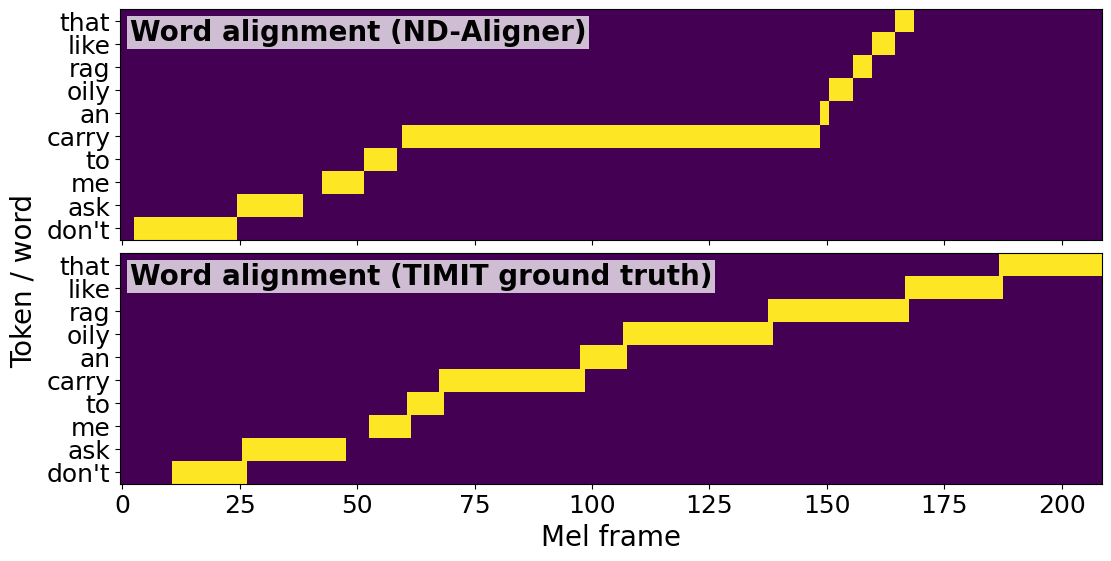

saved: figures/timit_alignment_example_SA2.pdf
saved: figures/timit_alignment_example_SA2.png


In [12]:
def plot_alignment_matrix(
    ax,
    mat: torch.Tensor,
    y_labels: list[str],
    title: str,
    title_pos: float,
    max_ticks: int = 80,
    *,
    show_xlabel: bool = False,
    ytick_fontsize: int = 9,
    label_fontsize: int = 11,
    panel_fontsize: int = 12,
):
    ax.imshow(
        mat.cpu().numpy(),
        aspect="auto",
        interpolation="nearest",
        origin="lower",
    )

    # Panel label/title inside the axis.
    ax.text(
        0.01,
        title_pos,
        title,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=panel_fontsize,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=2.0),
    )

    if show_xlabel:
        ax.set_xlabel("Mel frame", fontsize=label_fontsize)
    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)

    # ax.set_ylabel("Token / word", fontsize=label_fontsize)
    ax.tick_params(axis="both", labelsize=ytick_fontsize)

    if not y_labels:
        ax.set_yticks([])
        return

    step = max(1, math.ceil(len(y_labels) / max_ticks))
    ticks = list(range(0, len(y_labels), step))
    ax.set_yticks(ticks)
    ax.set_yticklabels([y_labels[i] for i in ticks], fontsize=ytick_fontsize)


fig_height = 5.5

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11.0, fig_height),
    constrained_layout=True,
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.0]},
)

plot_alignment_matrix(
    axes[0],
    model_word_mat_vis,
    model_word_labels_vis,
    "Word alignment (ND-Aligner)",
    0.96,
    ytick_fontsize=18,
    label_fontsize=14,
    panel_fontsize=20,
    show_xlabel=False,
)

plot_alignment_matrix(
    axes[1],
    gt_word_mat,
    gt_word_labels,
    "Word alignment (TIMIT ground truth)",
    0.96,
    ytick_fontsize=18,
    label_fontsize=20,
    panel_fontsize=20,
    show_xlabel=True,
)

# y label은 figure 전체에 대해 한 번만
fig.supylabel("Token / word", fontsize=20)

# fig.suptitle(f"TIMIT alignment example: {SAMPLE_STEM}", fontsize=14, fontweight="bold")

out_dir = Path("./figures")
out_dir.mkdir(parents=True, exist_ok=True)
out_pdf = out_dir / f"timit_alignment_example_{SAMPLE_STEM}.pdf"
out_png = out_dir / f"timit_alignment_example_{SAMPLE_STEM}.png"

fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("saved:", out_pdf)
print("saved:", out_png)

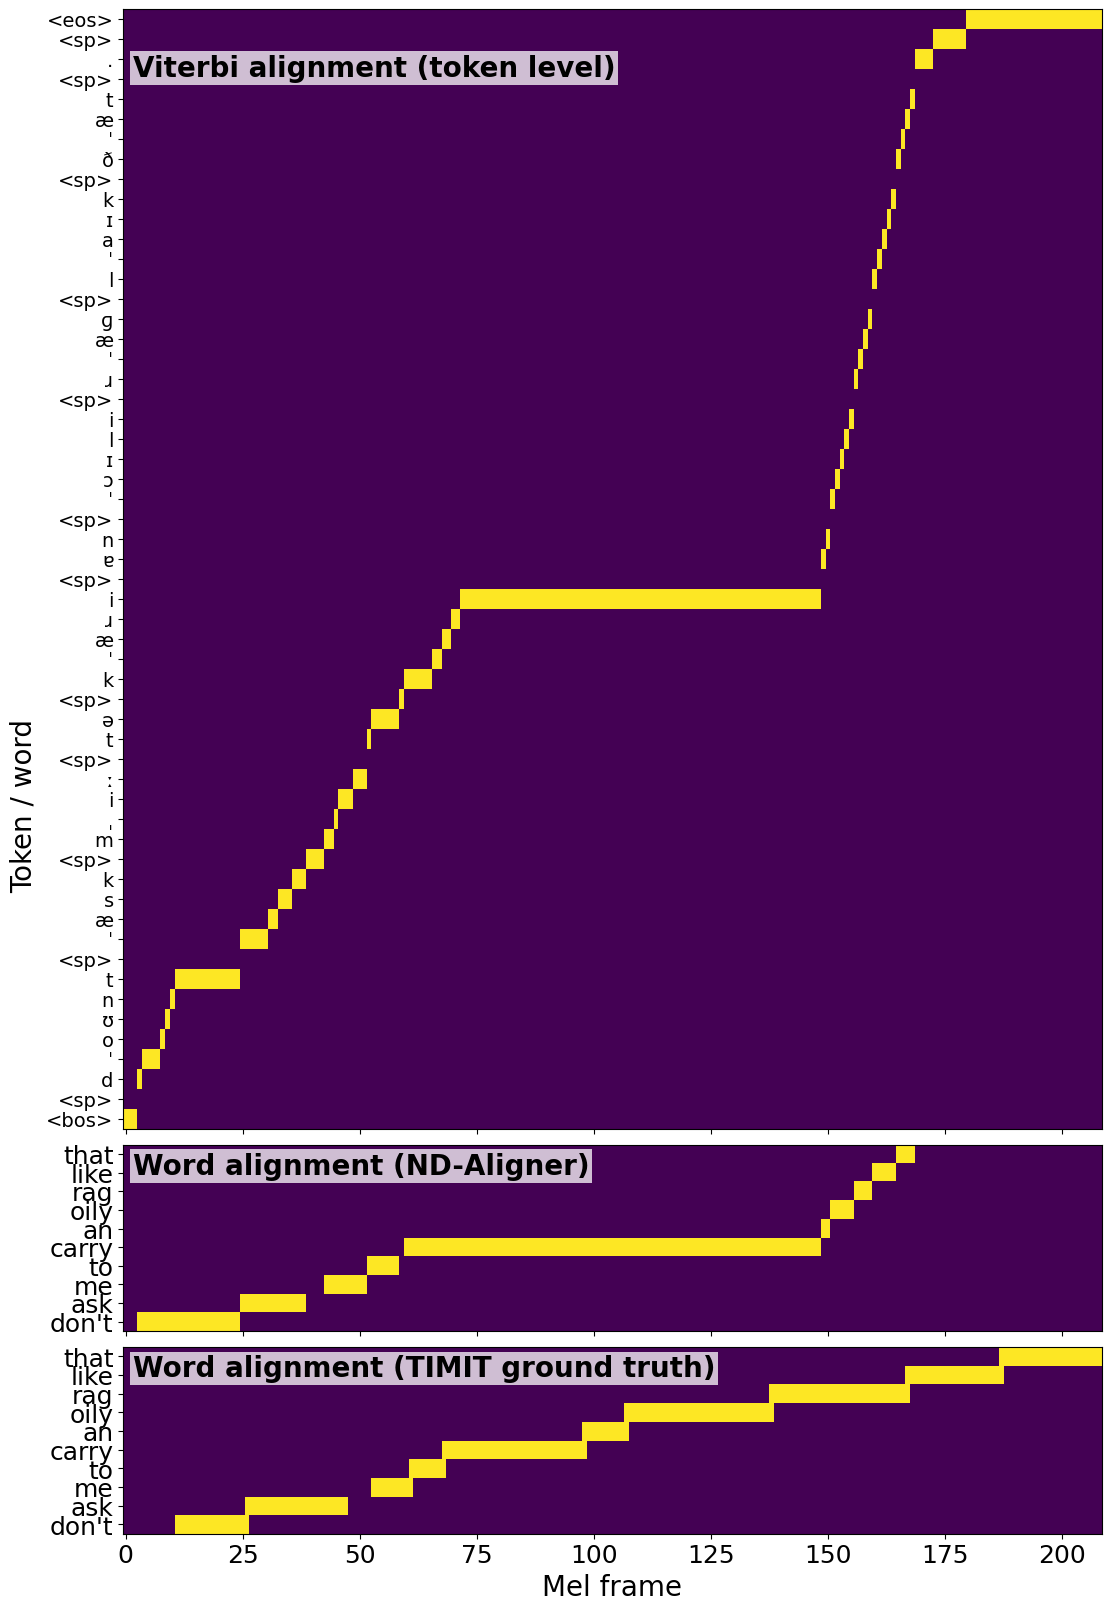

saved: figures/timit_alignment_example_SA2.pdf
saved: figures/timit_alignment_example_SA2.png


In [13]:
fig_height = 16.0

fig, axes = plt.subplots(
    3,
    1,
    figsize=(11.0, fig_height),
    constrained_layout=True,
    sharex=True,
    gridspec_kw={"height_ratios": [6.0, 1.0, 1.0]},
)

# ------------------------------------------------------------------
# Raw token-level Viterbi alignment
# ------------------------------------------------------------------
plot_alignment_matrix(
    axes[0],
    raw_model_mat,
    raw_model_labels,
    "Viterbi alignment (token level)",
    0.96,
    ytick_fontsize=14,
    label_fontsize=14,
    panel_fontsize=20,
    show_xlabel=False,
)

# ------------------------------------------------------------------
# Word-collapsed ND-Aligner alignment
# ------------------------------------------------------------------
plot_alignment_matrix(
    axes[1],
    model_word_mat_vis,
    model_word_labels_vis,
    "Word alignment (ND-Aligner)",
    0.96,
    ytick_fontsize=18,
    label_fontsize=14,
    panel_fontsize=20,
    show_xlabel=False,
)

# ------------------------------------------------------------------
# TIMIT ground truth
# ------------------------------------------------------------------
plot_alignment_matrix(
    axes[2],
    gt_word_mat,
    gt_word_labels,
    "Word alignment (TIMIT ground truth)",
    0.96,
    ytick_fontsize=18,
    label_fontsize=20,
    panel_fontsize=20,
    show_xlabel=True,
)

# Figure-wide y-axis label
fig.supylabel("Token / word", fontsize=20)

out_dir = Path("./figures")
out_dir.mkdir(parents=True, exist_ok=True)

out_pdf = out_dir / f"timit_alignment_example_{SAMPLE_STEM}.pdf"
out_png = out_dir / f"timit_alignment_example_{SAMPLE_STEM}.png"

fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, dpi=300, bbox_inches="tight")

plt.show()

print("saved:", out_pdf)
print("saved:", out_png)